<a href="https://colab.research.google.com/github/osoliman/HTM737/blob/main/Feedback_clean_axes_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hvbp.csv")
# Saved from week 10

df.head()
df.columns

Index(['Provider Number', 'Hospital Name', 'Address', 'City', 'State',
       'Zip Code', 'County Name',
       'Unweighted Normalized Clinical Care Domain Score',
       'Weighted Normalized Clinical Care Domain Score',
       'Unweighted Patient and Caregiver Centered Experience of Care/Care Coordination Domain Score',
       ...
       'Overall Rating of Hospital Floor',
       'Overall Rating of Hospital Achievement Threshold',
       'Overall Rating of Hospital Benchmark',
       'Overall Rating of Hospital Baseline Rate',
       'Overall Rating of Hospital Performance Rate',
       'Overall Rating of Hospital Achievement Points',
       'Overall Rating of Hospital Improvement Points',
       'Overall Rating of Hospital Dimension Score', 'HCAHPS Base Score',
       'HCAHPS Consistency Score'],
      dtype='object', length=170)

In [3]:
cols = [
    'Total Performance Score',
    'Weighted Normalized Clinical Care Domain Score',
    'Weighted Patient and Caregiver Centered Experience of Care/Care Coordination Domain Score',
    'Weighted Safety Domain Score',
    'Weighted Efficiency and Cost Reduction Domain Score'
        ]

#HVBP uses weighted score

df_cond = df[cols].copy()
df_cond.head()

#df_cond = condensed dataframe

,Total Performance Score,Weighted Normalized Clinical Care Domain Score,Weighted Patient and Caregiver Centered Experience of Care/Care Coordination Domain Score,Weighted Safety Domain Score,Weighted Efficiency and Cost Reduction Domain Score
0,35.547619047619,10.833333333333,6.500000000000,18.214285714286,0.000000000000
1,33.523809523810,4.166666666667,9.000000000000,20.357142857143,0.000000000000
2,22.702380952381,6.666666666667,4.250000000000,11.785714285714,0.000000000000
3,27.555555555556,8.888888888889,18.666666666667,Not Available,0.000000000000
4,28.630952380952,11.666666666667,6.250000000000,10.714285714286,0.000000000000


In [4]:
tps = df_cond.columns[0]
#tps = Total Performance Score

domains = df_cond.columns[1:]
#The four domains

In [5]:
#Had to do this to my file - not sure if you need to do the same to yours.
# Convert TPS and domain columns to numeric
tps = df_cond.columns[0]
domains = df_cond.columns[1:]

# Force conversion to numeric
df_cond[tps] = pd.to_numeric(df_cond[tps], errors='coerce')
for domain in domains:
    df_cond[domain] = pd.to_numeric(df_cond[domain], errors='coerce')

# Remove any rows with NaN values after conversion
df_cond = df_cond.dropna()

# Now check the range
print(f"TPS range: {df_cond[tps].min()} to {df_cond[tps].max()}")
print(f"TPS mean: {df_cond[tps].mean()}")

TPS range: 8.833333333333 to 71.75
TPS mean: 36.775216578344036


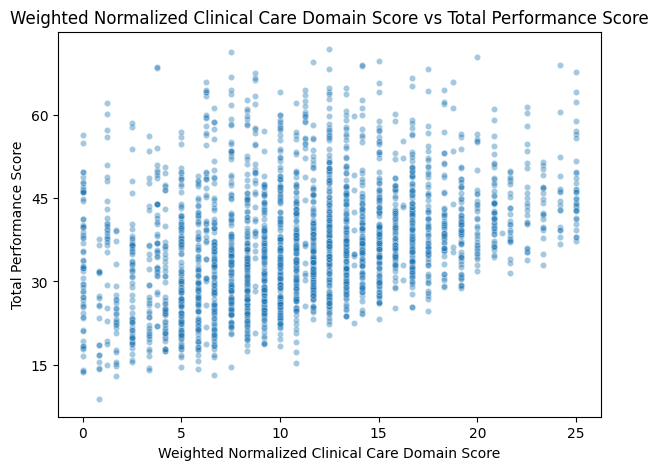

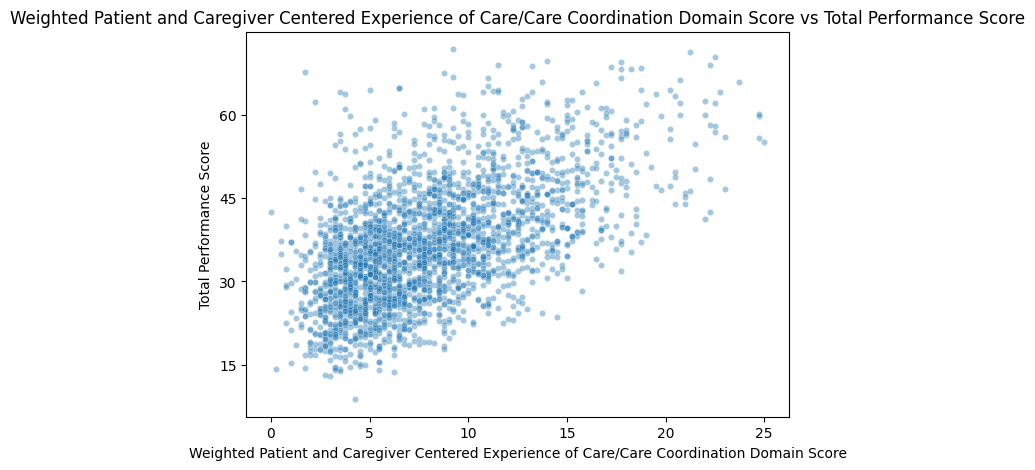

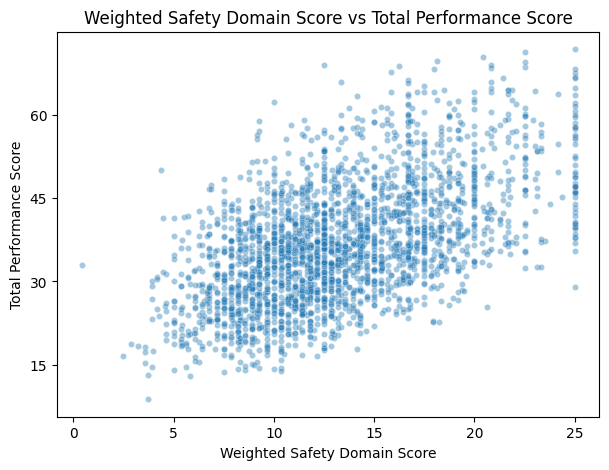

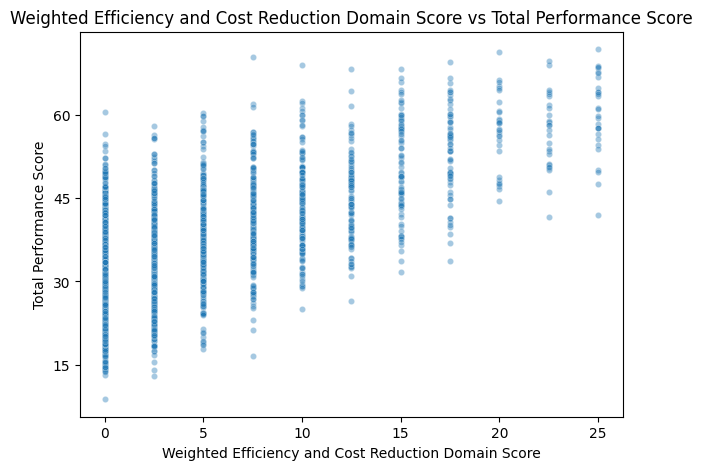

In [6]:
from matplotlib.ticker import MaxNLocator

for domain in domains:
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        x=df_cond[domain],
        y=df_cond[tps],
        alpha=0.4,
        s=20
    )

    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    plt.gca().xaxis.set_major_formatter('{x:.0f}')
    plt.gca().yaxis.set_major_formatter('{x:.0f}')

    plt.title(f'{domain} vs Total Performance Score')
    plt.xlabel(domain)
    plt.ylabel('Total Performance Score')
    plt.show()